In [17]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import warnings
import random
warnings.filterwarnings('ignore')

In [18]:

ds1_path = "/kaggle/input/datasets/zannatunnayemfahima/brain-mri/Datasest Merged 1"
ds2_path = "/kaggle/input/datasets/zannatunnayemfahima/brain-tumor-mri-dataset/Training"
ds3_path = "/kaggle/input/datasets/zannatunnayemfahima/mri-brain-tumor-dataset-4-class-7023-image/BT-MRI Dataset"

dataset_paths=np.array([ds1_path,ds2_path,ds3_path])

pituitary=np.array([])
no_tumor=np.array([])
meningioma=np.array([])
glioma=np.array([])

classes=np.array([pituitary,no_tumor,meningioma,glioma])

for ds in dataset_paths:
    count=-1
    for dirs in os.listdir(ds):
        paths=os.path.join(ds,dirs)
        count+=1
        for filename in os.listdir(paths):
            if count==0:
                pituitary=np.append(pituitary,os.path.join(paths,filename))
            elif count==1:
                no_tumor=np.append(no_tumor,os.path.join(paths,filename))
            elif count==2:
                meningioma=np.append(meningioma,os.path.join(paths,filename))
            elif count==3:
                glioma=np.append(glioma,os.path.join(paths,filename))

In [19]:
print(" Glioma:",len(glioma), "\n",
      "Meningioma:",len(meningioma), "\n",
      "Pituitary:",len(pituitary), "\n",
      "No-Tumor:",len(no_tumor), "\n",
     )

 Glioma: 1400 
 Meningioma: 1400 
 Pituitary: 1406 
 No-Tumor: 1400 



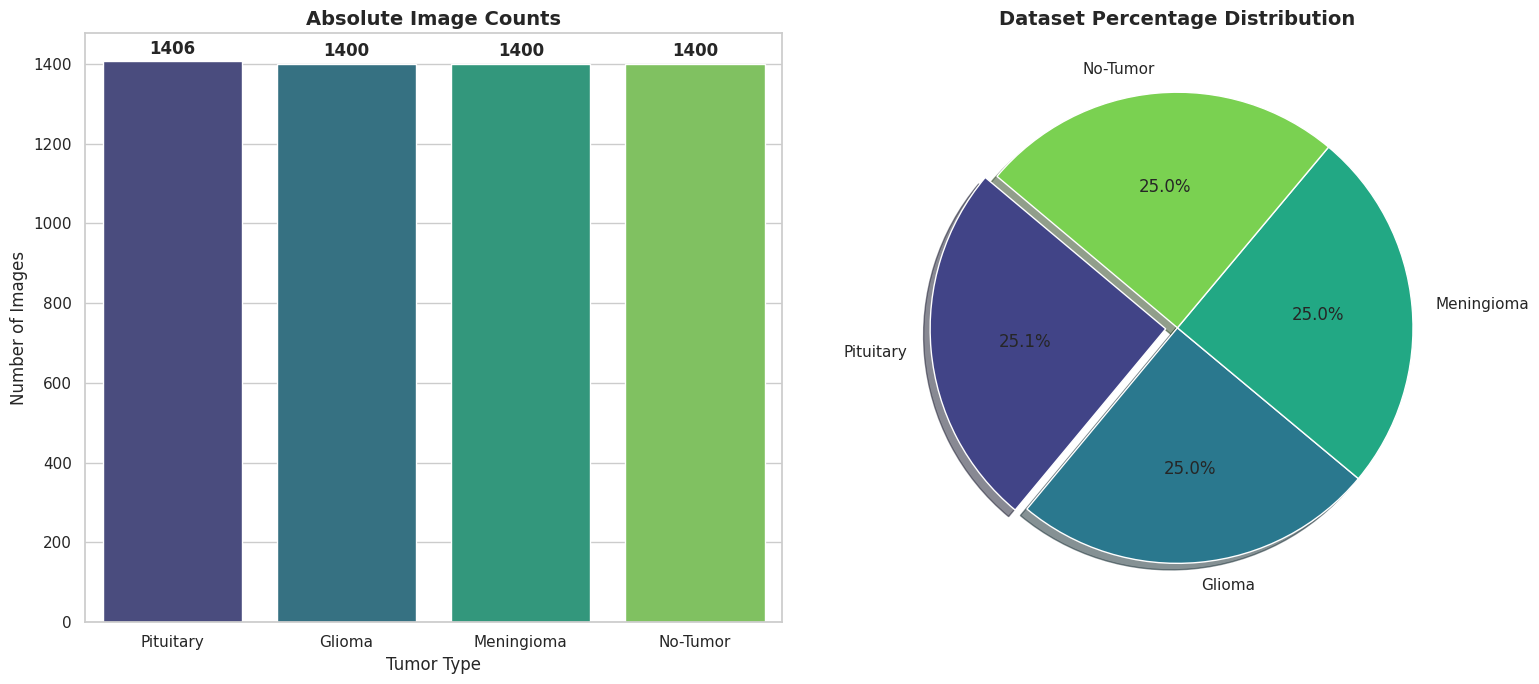

In [20]:
 #Prepare data from your arrays
data = {
    'Tumor Type': ['Glioma', 'Pituitary', 'Meningioma', 'No-Tumor'],
    'Count': [len(glioma), len(pituitary), len(meningioma), len(no_tumor)]
}
df = pd.DataFrame(data).sort_values(by='Count', ascending=False)

# 2. Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Bar Plot ---
sns.barplot(x='Tumor Type', y='Count', data=df, palette='viridis', ax=ax1)
ax1.set_title('Absolute Image Counts', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Images')

# Adding labels to bars
for p in ax1.patches:
    ax1.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontweight='bold')

# --- Right: Pie Chart ---
colors = sns.color_palette('viridis', len(df))
ax2.pie(df['Count'], labels=df['Tumor Type'], autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=[0.05, 0, 0, 0], shadow=True)
ax2.set_title('Dataset Percentage Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

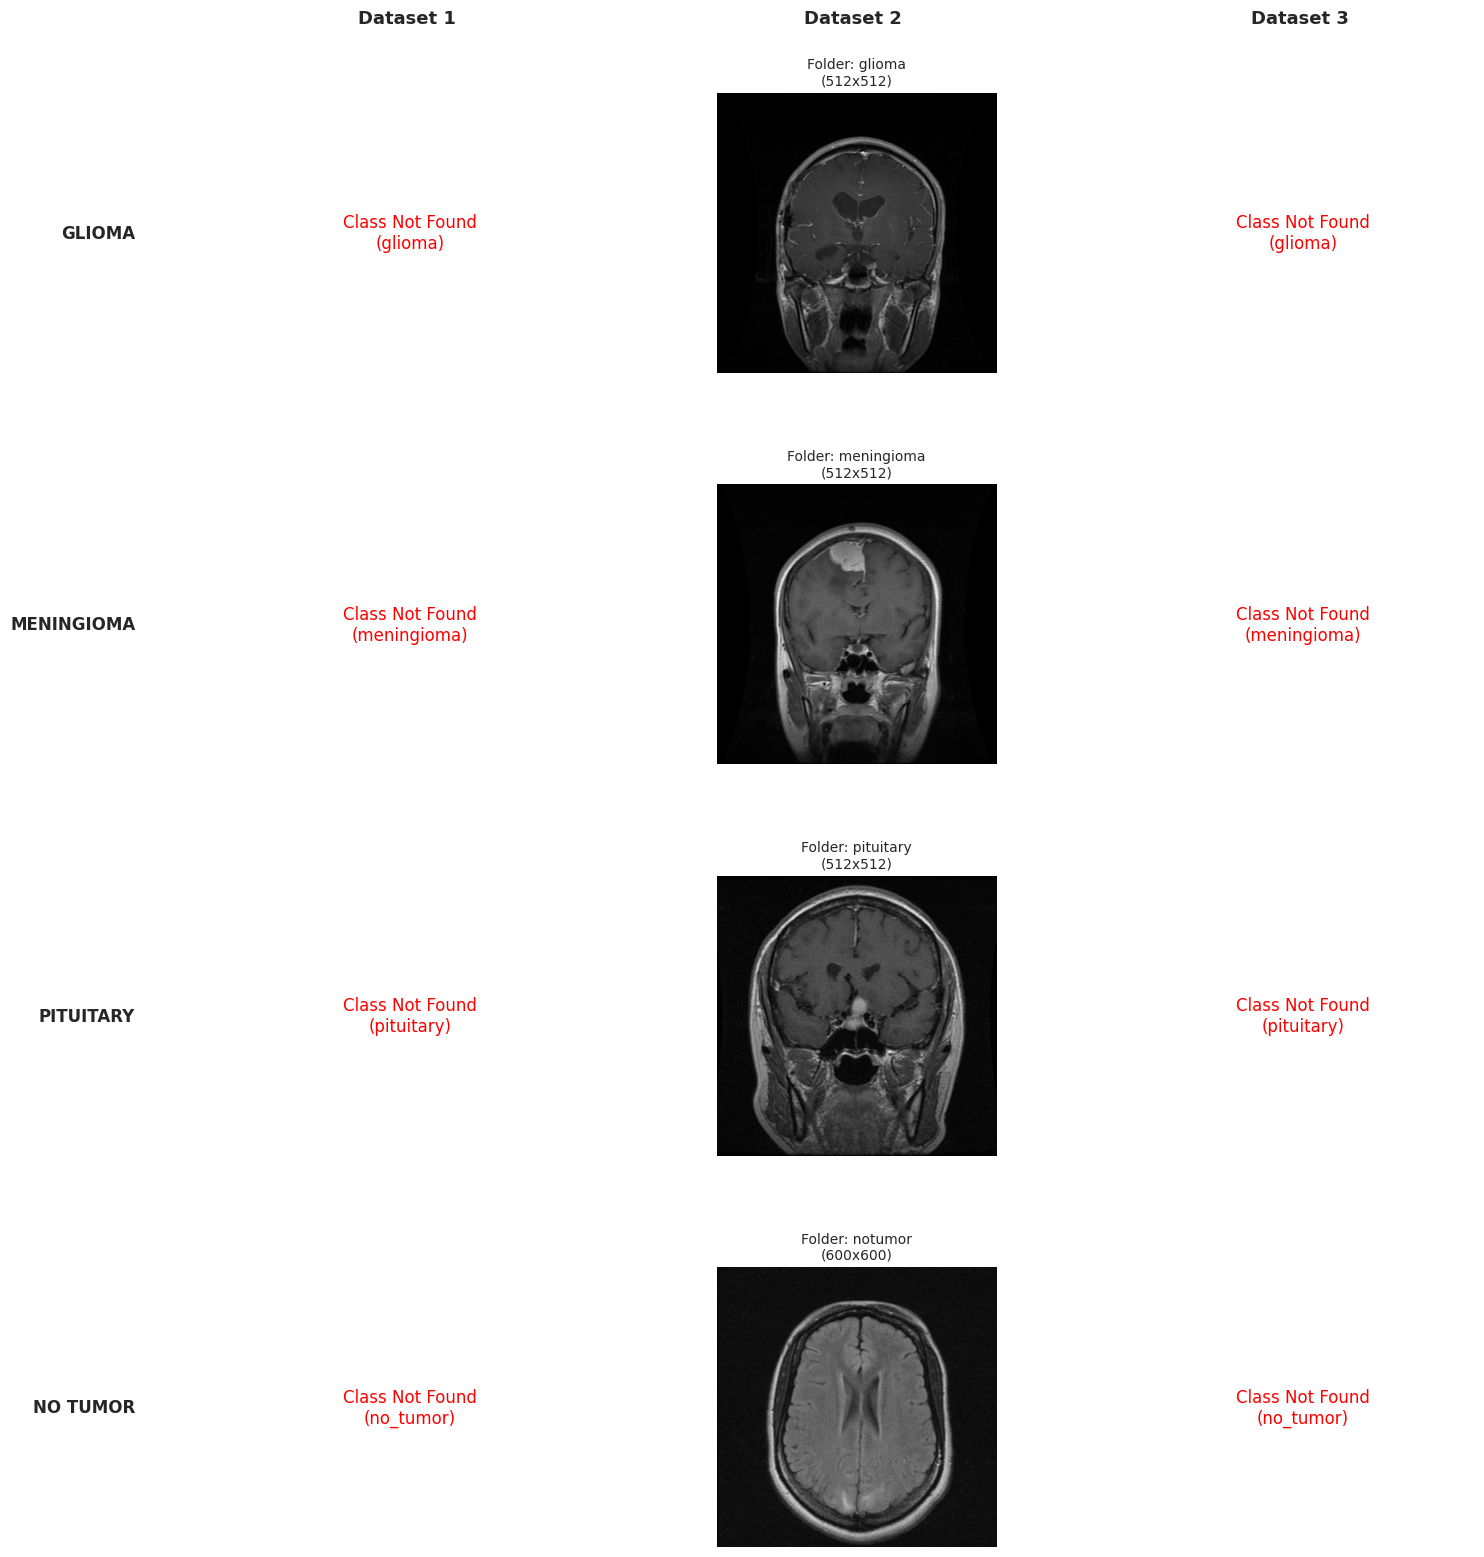

In [21]:
dataset_paths = [ds1_path, ds2_path, ds3_path]
dataset_names = ["Dataset 1 ", "Dataset 2 ", "Dataset 3 "]

# Normalized standard classes we want to map to
standard_classes = ["glioma", "meningioma", "pituitary", "no_tumor"]

# Create a grid: 4 rows (classes) x 3 columns (datasets)
fig, axes = plt.subplots(len(standard_classes), len(dataset_paths), figsize=(15, 16))

# Helper function to find the best folder match regardless of exact naming/case
def find_matching_folder(base_path, target_cls):
    if not os.path.exists(base_path):
        return None
    for folder in os.listdir(base_path):
        if os.path.isdir(os.path.join(base_path, folder)):
            # Clean names for comparison (lowercase, remove underscores/spaces)
            clean_folder = folder.lower().replace("_", "").replace(" ", "").replace("tumor", "")
            clean_target = target_cls.lower().replace("_", "").replace(" ", "").replace("tumor", "")
            if clean_target in clean_folder or clean_folder in clean_target:
                return folder
    return None

# Loop through columns (datasets) and rows (classes)
for col_idx, path in enumerate(dataset_paths):
    for row_idx, std_cls in enumerate(standard_classes):
        ax = axes[row_idx, col_idx]
        
        # Find the actual folder name in this specific dataset
        matched_folder = find_matching_folder(path, std_cls)
        
        if matched_folder:
            cls_folder = os.path.join(path, matched_folder)
            images = [f for f in os.listdir(cls_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            if images:
                random_img = random.choice(images)
                img_path = os.path.join(cls_folder, random_img)
                
                # Read using OpenCV
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    ax.imshow(img)
                    # Label with the folder name found in that specific dataset + dimensions
                    ax.set_title(f"Folder: {matched_folder}\n({img.shape[1]}x{img.shape[0]})", fontsize=10)
                else:
                    ax.text(0.5, 0.5, "Read Error", ha='center', va='center', color='red')
            else:
                ax.text(0.5, 0.5, "No Images Found", ha='center', va='center', color='orange')
        else:
            ax.text(0.5, 0.5, f"Class Not Found\n({std_cls})", ha='center', va='center', color='red')
            
        ax.axis('off')

# Add Column Titles at the very top of the grid
for col_idx, name in enumerate(dataset_names):
    axes[0, col_idx].text(0.5, 1.25, name, fontsize=13, fontweight='bold', 
                          ha='center', transform=axes[0, col_idx].transAxes)

# Add Row Labels on the far left side
for row_idx, std_cls in enumerate(standard_classes):
    axes[row_idx, 0].text(-0.3, 0.5, std_cls.upper().replace("_", " "), fontsize=12, fontweight='bold',
                          va='center', ha='right', transform=axes[row_idx, 0].transAxes, rotation=0)

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.4, wspace=0.3)
plt.show()

This is a new line.